# Taller Análisis Exploratorio de Datos

## Integrantes

- Juan Pablo Cardona Bedoya
- Felipe Villa Jaramillo

## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [UCI](https://archive.ics.uci.edu/dataset/27/credit+approval).

De a las columnas los siguientes nombres: 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15'.

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
    - Tiene 690 filas y 16 columnas en total.   
- ¿De qué tipo de dato es cada columna?

| # | Columna | Dtype |
|---|---------|---------|
| 0 | A0 | str |
| 1 | A1 | float64 |
| 2 | A2 | float64 |
| 3 | A3 | str |
| 4 | A4 | str |
| 5 | A5 | str |
| 6 | A6 | str |
| 7 | A7 | float64 |
| 8 | A8 | str |
| 9 | A9 | str |
| 10 | A10 | int64 |
| 11 | A11 | str |
| 12 | A12 | str |
| 13 | A13 | float64 |
| 14 | A14 | int64 |
| 15 | A15 | str |
- ¿Las variables están en el tipo de dato correcto para su contenido?
    - Sí tienen el tipo de dato correcto inferido. Se pueden mejorar algunos ccategóricos para tomarlos como booleano o convertirlo en 0 y 1


In [24]:
from pathlib import Path

DATA_DIR = Path().resolve().parent / "Taller_1" / "data" / "raw"
data_file = "crx.data"
data_path = DATA_DIR / data_file

import pandas as pd

df = pd.read_csv(
    data_path,
    names=['A0','A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15'],
    na_values=['?']
    )

# df.head()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A0      678 non-null    str    
 1   A1      678 non-null    float64
 2   A2      690 non-null    float64
 3   A3      684 non-null    str    
 4   A4      684 non-null    str    
 5   A5      681 non-null    str    
 6   A6      681 non-null    str    
 7   A7      690 non-null    float64
 8   A8      690 non-null    str    
 9   A9      690 non-null    str    
 10  A10     690 non-null    int64  
 11  A11     690 non-null    str    
 12  A12     690 non-null    str    
 13  A13     677 non-null    float64
 14  A14     690 non-null    int64  
 15  A15     690 non-null    str    
dtypes: float64(4), int64(2), str(10)
memory usage: 86.4 KB


## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

In [25]:
df.describe()

,A1,A2,A7,A10,A13,A14
count,678.000000,690.000000,690.000000,690.00000,677.000000,690.000000
mean,31.568171,4.758725,2.223406,2.40000,184.014771,1017.385507
std,11.957862,4.978163,3.346513,4.86294,173.806768,5210.102598
min,13.750000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,22.602500,1.000000,0.165000,0.00000,75.000000,0.000000
50%,28.460000,2.750000,1.000000,0.00000,160.000000,5.000000
75%,38.230000,7.207500,2.625000,3.00000,276.000000,395.500000
max,80.250000,28.000000,28.500000,67.00000,2000.000000,100000.000000


In [26]:
df.describe(include='str')

,A0,A3,A4,A5,A6,A8,A9,A11,A12,A15
count,678,684,684,681,681,690,690,690,690,690
unique,2,3,3,14,9,2,2,2,3,2
top,b,u,g,c,v,t,f,f,g,-
freq,468,519,519,137,399,361,395,374,625,383


## Paso 2 Respuestas

Responda las siguientes preguntas:
1. Según la documentación del dataset todos los datos tienen valores dentro del rango establecido y no hay valores imposibles
2. No, no hay variables que NO varíen, todas están al menos con 2 valores diferentes lo cual hace que aporten información al modelo.
3. Las variables que presentan alta cardinalidad son la A5 y A6 ya que son las que más posibles valores toman respecto a las demás del dataset.
4. No, en el dataset no se encuentran llaves primarias que identifiquen cada registro

## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

In [27]:
df.isnull().sum().sort_values(ascending=False)*100/df.shape[0]

A13    1.884058
A0     1.739130
A1     1.739130
A6     1.304348
A5     1.304348
A4     0.869565
A3     0.869565
A2     0.000000
A7     0.000000
A8     0.000000
A10    0.000000
A9     0.000000
A11    0.000000
A12    0.000000
A14    0.000000
A15    0.000000
dtype: float64

In [28]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  0


## Paso 3 Respuestas

1. Las variables que tienen valores nulos son: A0, A1,A3,A4,A5,A6,A13 y tienen una proporción muy baja de valores nulos:

| Columna | Valor |
|---------|-------|
| A13 | 1.8840579710144927 |
| A0 | 1.7391304347826086 |
| A1 | 1.7391304347826086 |
| A6 | 1.3043478260869565 |
| A5 | 1.3043478260869565 |
| A4 | 0.8695652173913043 |
| A3 | 0.8695652173913043 |

2. No hay registros duplicados en el dataset
3. No hay problemas de formateo con las variables en el dataset porque no hay valores que requieran de un formato específico.

## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

In [29]:
#Extraemos las variables numéricas para verificar el supuesto de normalidad

num_vars = df.select_dtypes(include=["number"]).columns
print('Variables numéricas: ', num_vars)

# Verificar supuesto de normalidad con prueba de Kolmogorov-Smirnov
from scipy.stats import kstest, norm

for num in num_vars:
    data = df[num].dropna()
    __, p_value = kstest(data, norm.cdf, args=(data.mean(), data.std()))
    print(f"Prueba de Kolmogorov-Smirnov para {num}:")
    print(f"  Valor p: {p_value}")
    if p_value > 0.05:
        print(f"  {num} parece ser normal (no se rechaza la hipótesis nula)")
    else:
        print(f"  {num} no parece ser normal (se rechaza la hipótesis nula)")
    print()


Variables numéricas:  Index(['A1', 'A2', 'A7', 'A10', 'A13', 'A14'], dtype='str')
Prueba de Kolmogorov-Smirnov para A1:
  Valor p: 1.0331118517919018e-07
  A1 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A2:
  Valor p: 1.3014031904956561e-18
  A2 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A7:
  Valor p: 1.7508115416087983e-39
  A7 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A10:
  Valor p: 1.0376830545783983e-59
  A10 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A13:
  Valor p: 7.328091783236187e-13
  A13 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A14:
  Valor p: 2.949727065225186e-112
  A14 no parece ser normal (se rechaza la hipótesis nula)



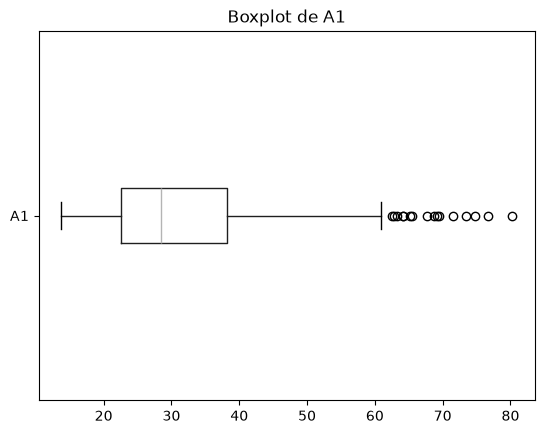

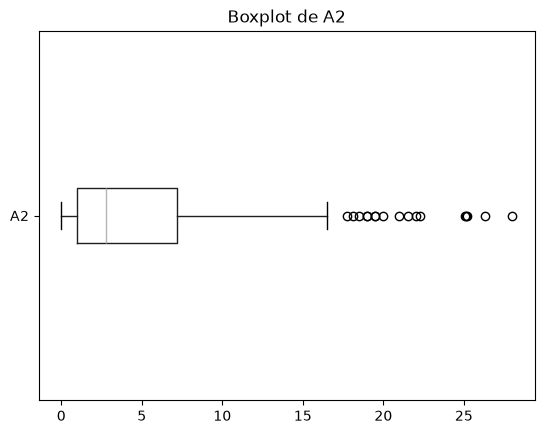

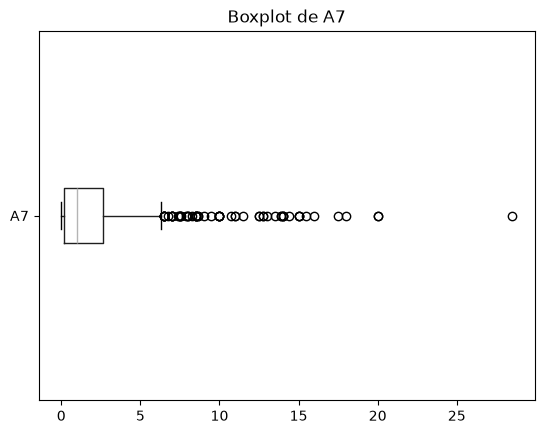

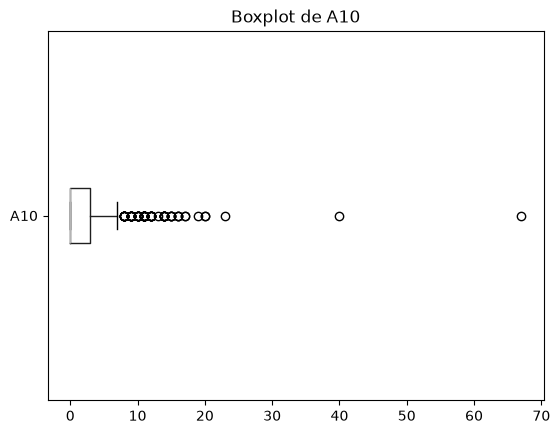

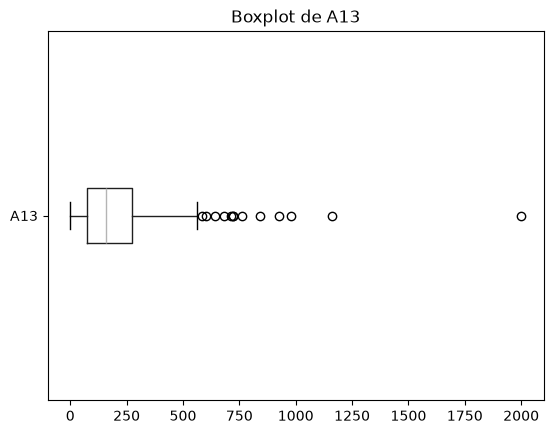

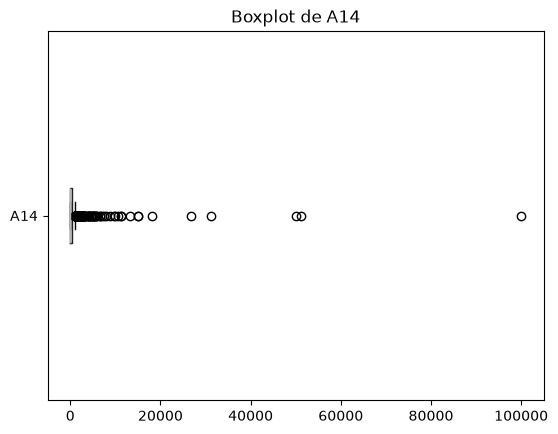

In [30]:
import matplotlib.pyplot as plt

for num in num_vars:
    plt.figure()
    df.boxplot(column=num, grid=False, vert=False)
    plt.title(f'Boxplot de {num}')
    plt.show()

## Paso 4 Respuesta

1. Ninguna de las variables continuas que tenemos en el dataset cumplen con el supuesto de normalidad
2. Según el análisis gráfico de los outliers en general todos tienen datos atípicos (A14, A13, A10, A7, A2, A1). Algunos se encuentran menos dispersos pero para casos como la del A14 si tiene valores muy críticos como outliers

## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

In [31]:
cat_vars = df.select_dtypes(include=['object']).columns

for var in cat_vars:
    print(f'El conteo de la variable {var} es: \n {df[var].value_counts()} \n')

El conteo de la variable A0 es: 
 A0
b    468
a    210
Name: count, dtype: int64 

El conteo de la variable A3 es: 
 A3
u    519
y    163
l      2
Name: count, dtype: int64 

El conteo de la variable A4 es: 
 A4
g     519
p     163
gg      2
Name: count, dtype: int64 

El conteo de la variable A5 es: 
 A5
c     137
q      78
w      64
i      59
aa     54
ff     53
k      51
cc     41
m      38
x      38
d      30
e      25
j      10
r       3
Name: count, dtype: int64 

El conteo de la variable A6 es: 
 A6
v     399
h     138
bb     59
ff     57
j       8
z       8
dd      6
n       4
o       2
Name: count, dtype: int64 

El conteo de la variable A8 es: 
 A8
t    361
f    329
Name: count, dtype: int64 

El conteo de la variable A9 es: 
 A9
f    395
t    295
Name: count, dtype: int64 

El conteo de la variable A11 es: 
 A11
f    374
t    316
Name: count, dtype: int64 

El conteo de la variable A12 es: 
 A12
g    625
s     57
p      8
Name: count, dtype: int64 

El conteo de la variable 

/tmp/ipykernel_273899/3338964807.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_vars = df.select_dtypes(include=['object']).columns


## Paso 5 Respuestas

1. En general se ven dos patrones distintos entre las variables categóricas: unas están razonablemente balanceadas entre sus categorías (A0, A8, A9, A11 y la variable objetivo A15, todas binarias sin una proporción extrema), y otras tienen una categoría dominante con el resto casi vacío (A3: u=519, y=163, l=2; A4: g=519, p=163, gg=2; A12: g=625, s=57, p=8).
2. Sí, A5 (14 categorías: c, q, w, i, aa, ff, k, cc, m, x, d, e, j, r) y A6 (9 categorías: v, h, bb, ff, j, z, dd, n, o) presentan alta cardinalidad frente al resto de las categóricas, que solo tienen entre 2 y 3 valores posibles.
3. Sí, hay varias categorías con muy pocos registros: A3 con `l` (2 registros), A4 con `gg` (2), A12 con `p` (8), y dentro de A5 y A6 varias categorías con menos de 10 registros (A5: `r`=3, `j`=10; A6: `o`=2, `n`=4, `dd`=6). Al tener tan pocos casos, un modelo tendría muy poca evidencia para aprender su efecto individual.

## Paso 6: Análisis bivariado

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la vaariable **A15**.


Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?


<Axes: >

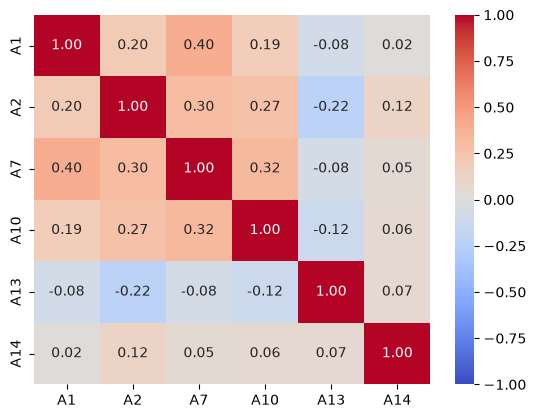

In [32]:
import seaborn as sns

corr = df.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

### Relación de las variables cuantitativas con A15


<Figure size 640x480 with 0 Axes>

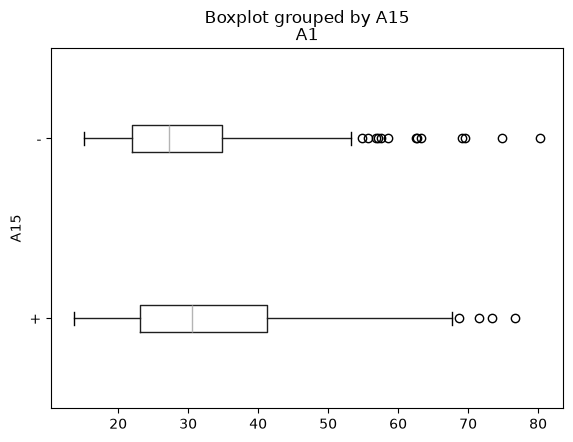

<Figure size 640x480 with 0 Axes>

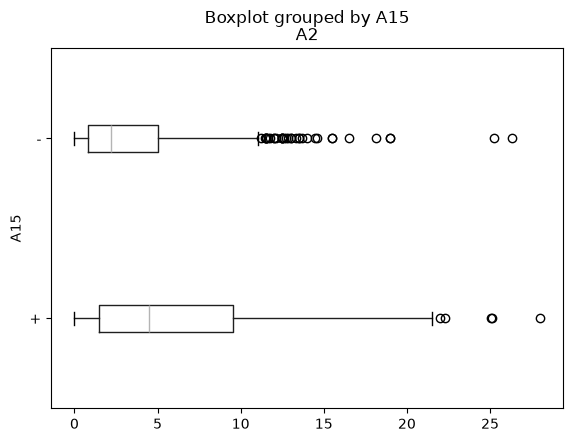

<Figure size 640x480 with 0 Axes>

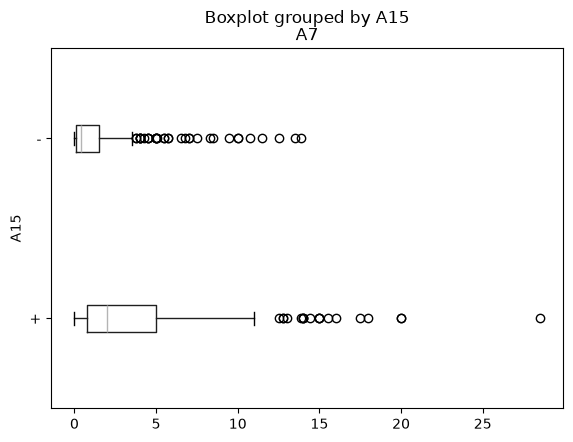

<Figure size 640x480 with 0 Axes>

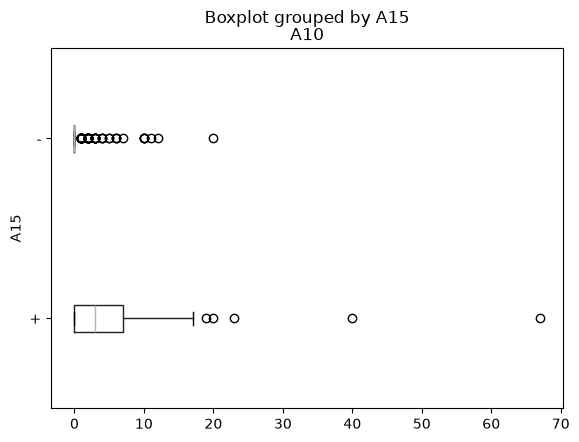

<Figure size 640x480 with 0 Axes>

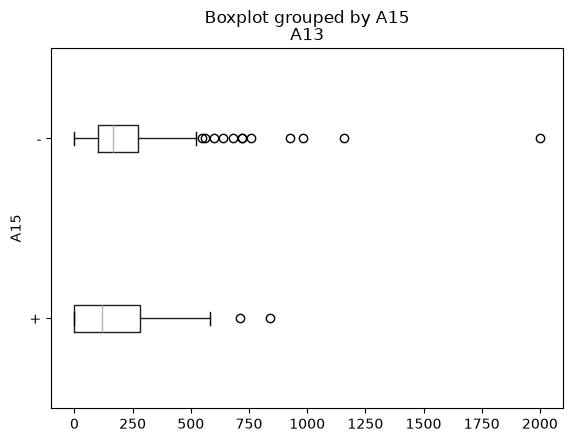

<Figure size 640x480 with 0 Axes>

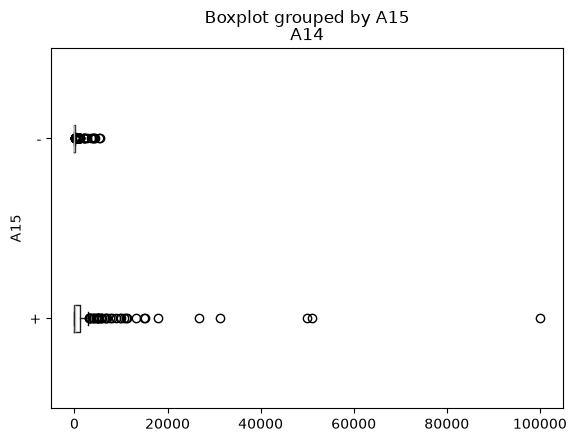

In [33]:
for var in num_vars:
    plt.figure()
    df.boxplot(column=var, by="A15", grid=False, vert=False)
    plt.show()

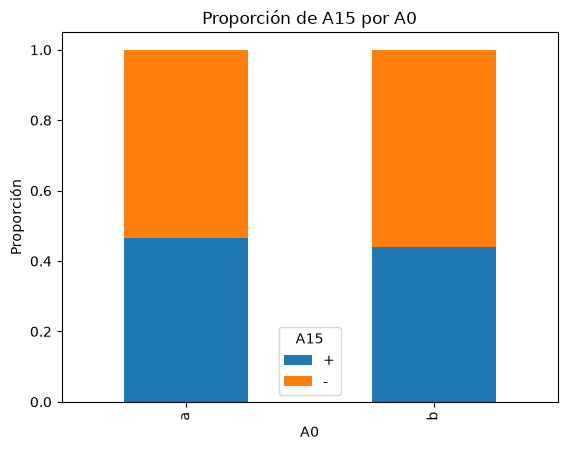

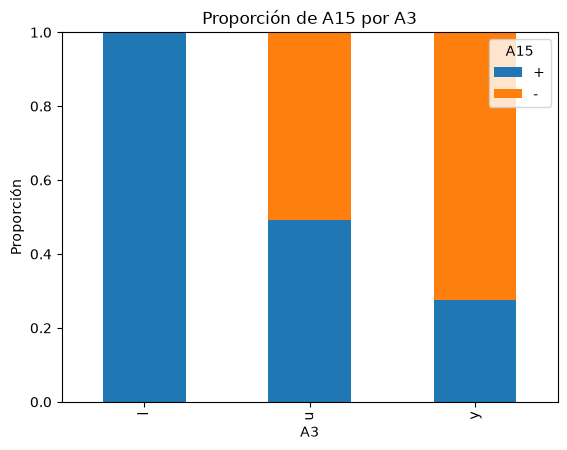

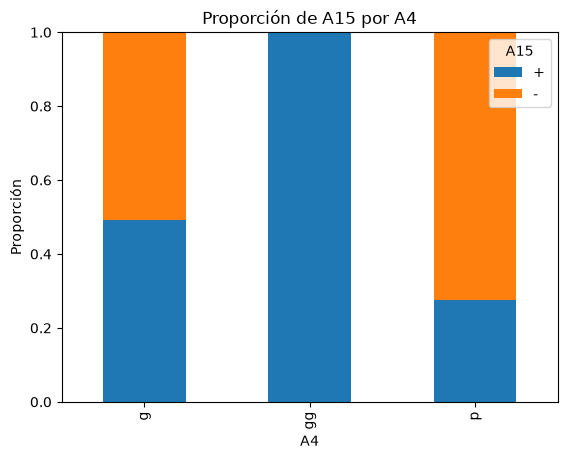

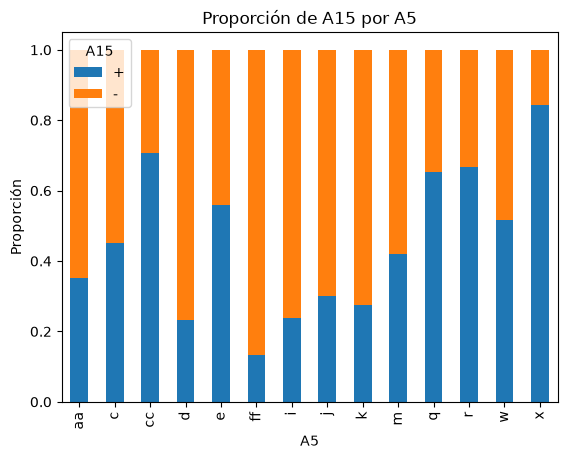

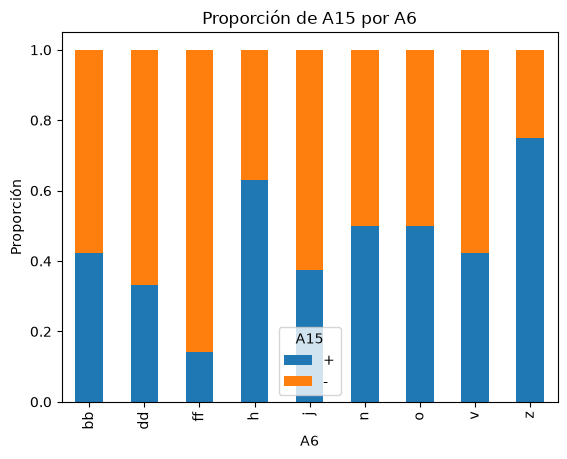

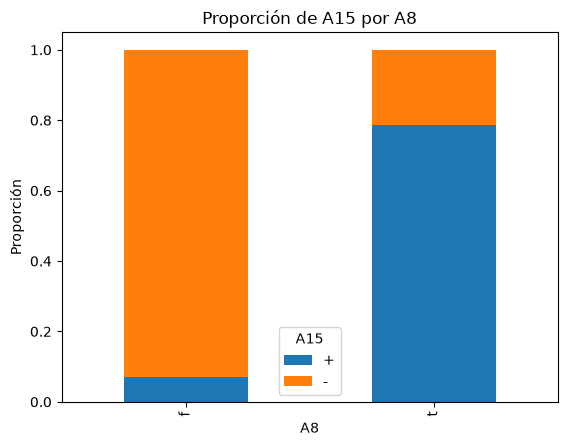

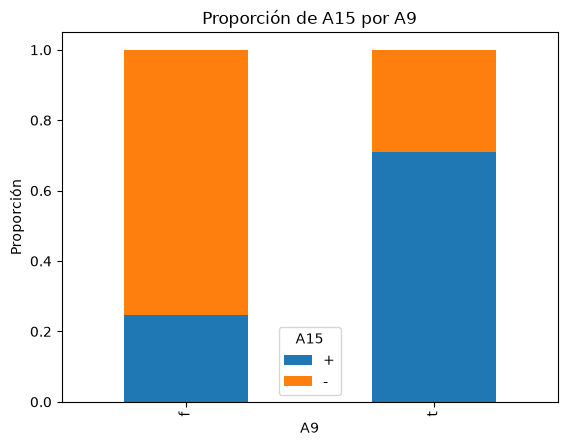

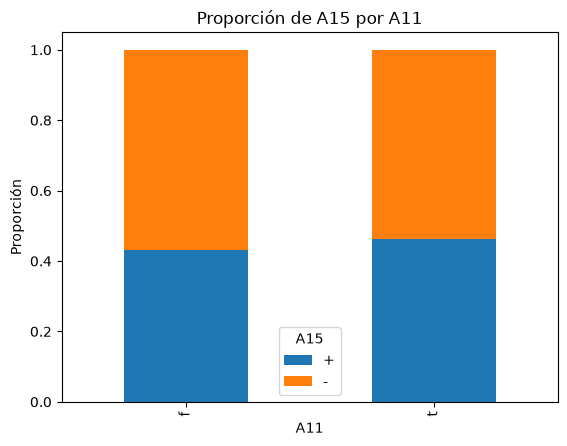

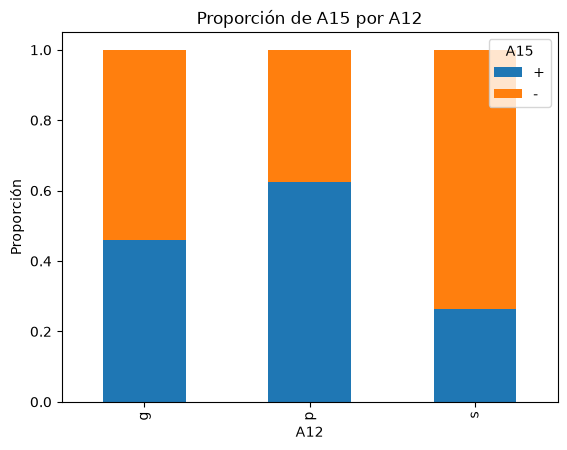

In [34]:
cat_vars_predictors = cat_vars.drop('A15')

for var in cat_vars_predictors:
    tabla = pd.crosstab(df[var], df['A15'], normalize='index')
    tabla.plot.bar(stacked=True)
    plt.title(f'Proporción de A15 por {var}')
    plt.ylabel('Proporción')
    plt.show()

## Paso 6 Respuestas

1. Las cuantitativas que más se relacionan con A15 son A7, A10 y A14, porque los aprobados (+) tienen valores bastante más altos que los rechazados (por ejemplo A14 tiene media de 2038 en aprobados contra 198 en rechazados). A1 y A2 también cambian un poco entre grupos pero no tan marcado, y A13 casi no varía (incluso los aprobados salen con mediana un poco más baja, 120 contra 167.5).
2. En las categóricas se nota bastante diferencia en A8 y A9 (en A8 los que tienen t tienen 79% de aprobados y los que tienen f solo 7%). A5, A6 y A12 también muestran diferencias según la categoría. A0 y A11 en cambio casi no cambian, el porcentaje de aprobados se mantiene parecido sin importar la categoría.
3. Entonces las que parecen buenas predictoras son A7, A8, A9, A10 y A14, y en menor medida A5, A6, A12, A1 y A2. Las que no aportan mucho son A0, A11 y A13 porque se comportan casi igual en las dos clases.